---
numbering: false
---

# 1.4. Comparing Loss Functions

We now know that:

- The mean is the constant prediction that minimizes mean squared error.

    $$R_\text{sq}(w) = \frac{1}{n} \sum_{i=1}^n (y_i - w)^2 \implies w^* = \text{Mean}(y_1, y_2, \ldots, y_n)$$

- The median is the constant prediction that minimizes mean absolute error.

    $$R_\text{abs}(w) = \frac{1}{n} \sum_{i=1}^n |y_i - w| \implies w^* = \text{Median}(y_1, y_2, \ldots, y_n)$$

Let's compare the behavior of the mean and median, and reason about how their differences in behavior are related to the differences in the loss functions used to derive them.

## Outliers and Balance

Let's consider our example dataset of 5 commute times, with a mean of 85 and median of 80:
$$61 \qquad 72 \qquad 85 \qquad 90 \qquad 92$$

Suppose 200 is added to the largest commute time:
$$61 \qquad 72 \qquad 85 \qquad 90 \qquad 292$$
The median is still 85, but the mean is now $80 + \frac{200}{5} = 120$. This example illustrates the fact that the mean is sensitive to outliers, while the median is **robust** to outliers.

But why? I like to think of the mean and median as different "balance points" of a dataset, each satisfying a different "balance condition".

| Summary Statistic | Minimizes | Balance Condition<br>(comes from setting $\frac{\text{d}}{\text{d}w} R(w) = 0$) |
| --- | --- | --- |
| Median | $\displaystyle R_\text{abs}(w) = \frac{1}{n} \sum_{i=1}^n \|y_i - w\|$ | $\text{\# left of } w = \text{\# right of } w$ |
| Mean | $\displaystyle R_\text{sq}(w) = \frac{1}{n} \sum_{i=1}^n (y_i - w)^2$ |  $\displaystyle\sum_{i=1}^n (y_i - w) = 0$ |

In both cases, the "balance condition" comes from setting the derivative of empirical risk, $\frac{\text{d}}{\text{d}w} R(w)$, to 0. The logic for the median and mean absolute error is more fresh from this section, so let's think in terms of the mean and mean squared error, from [Chapter 1.2](02-squared-loss-constant-model.ipynb#minimizing-mean-squared-error). There, we found that:

$$\displaystyle \frac{\text{d}}{\text{d}w} R_\text{sq}(w) = -\frac{2}{n} \sum_{i=1}^n (y_i - w)$$

Setting this to 0 gave us the balance equation above.

$$\sum_{i=1}^n (y_i - w^*) = 0$$

In English, this is saying that the sum of **deviations** from each data point to the mean is 0. ("Deviation" just means "difference from the mean.) Or, in other words, the positive differences and negative differences cancel each other out at the mean, and the mean is the unique point where this happens. 

Let me illustrate using our familiar small example dataset.

$$61 \qquad 72 \qquad 85 \qquad 90 \qquad 92$$

The mean is 80. Then:

$$
\underbrace{(61 - 80)}_{\color{#d81b60}{-19}} + 
\underbrace{(72 - 80)}_{\color{#d81b60}{-8}} + 
\underbrace{(85 - 80)}_{\color{#3d81f6}{5}} + 
\underbrace{(90 - 80)}_{\color{#3d81f6}{10}} + 
\underbrace{(92 - 80)}_{\color{#3d81f6}{12}} = 0
$$

Note that the <span style="color:#d81b60; font-weight:bold">negative deviations</span> and <span style="color:#3d81f6; font-weight:bold">positive deviations</span> both total $27$ in magnitude.

While the mean balances the positive and negative deviations, the median balances the number of points on either side, without regard to how far the values are from the median.

Here's another perspective: the squared loss more heavily penalizes outliers, and so the resulting predictions "cater to" or are "pulled" towards these outliers.

We just derived the absolute-loss solution for the constant model; now we'll compare it to squared loss and examine how the choice of loss changes what “best” means.

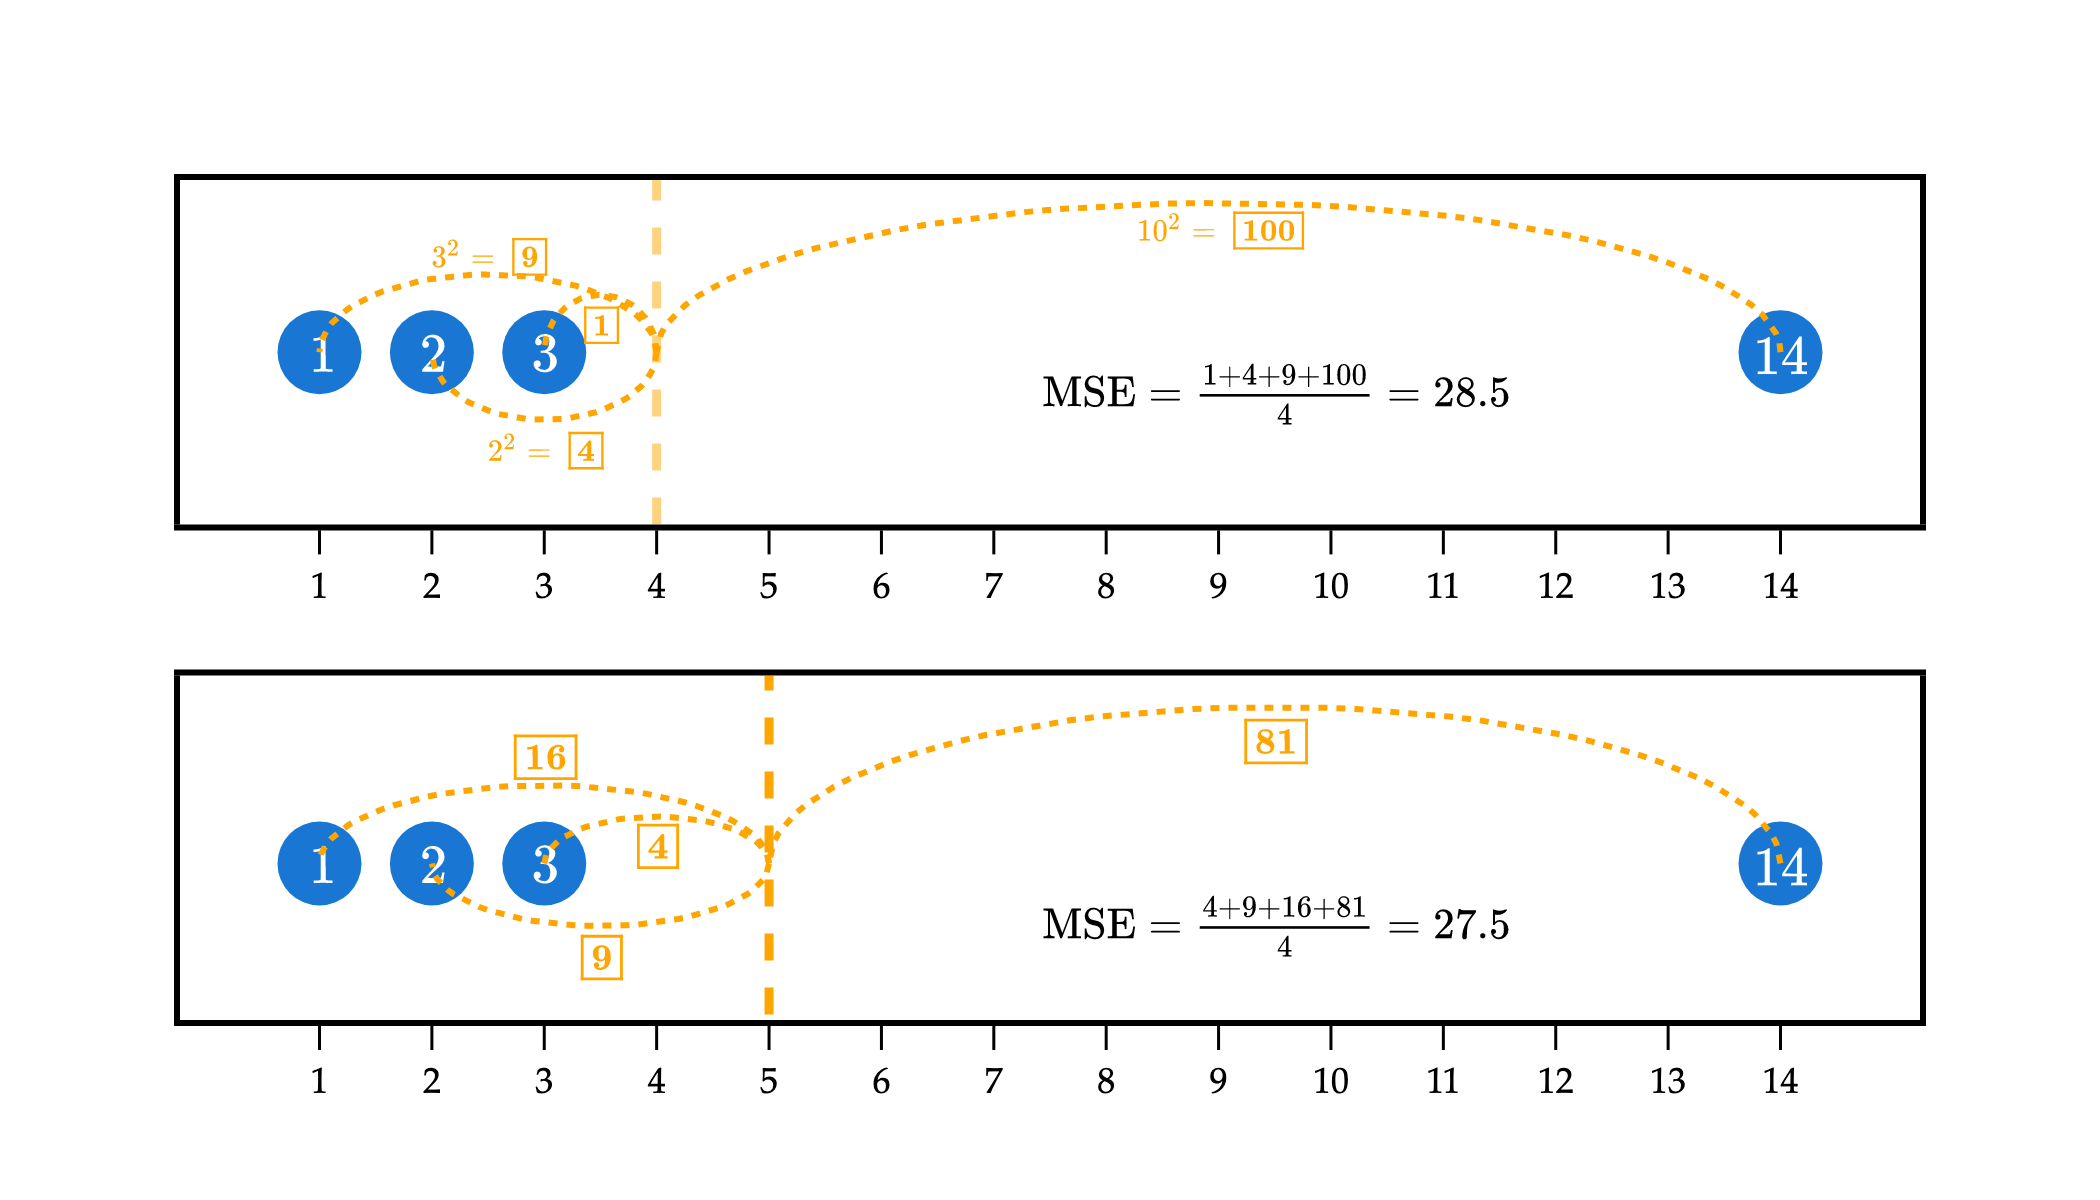

In [37]:
import plotly.graph_objects as go
import numpy as np
from plotly.subplots import make_subplots

# Data points
commute_times = [1, 2, 3, 14]
mean_val = np.mean(commute_times)   # 5.0
median_val = np.median(commute_times)  # 2.5

# Function to create arc coordinates
def create_arc(x1, x2, height=0.8, num_points=50):
    """Create arc coordinates between two x points"""
    t = np.linspace(0, np.pi, num_points)
    x_center = (x1 + x2) / 2
    x_radius = abs(x2 - x1) / 2
    
    x_arc = x_center + x_radius * np.cos(t)
    y_arc = height * np.sin(t)
    
    return x_arc, y_arc

# --- Top image: Outlier illustration (with arc annotations) ---
h_ref = 4

# Prepare traces for top plot
top_traces = []
# Reference line at h=4
top_traces.append(go.Scatter(
    x=[h_ref, h_ref],
    y=[-1.5, 1.5],
    mode='lines',
    line=dict(color="orange", width=3, dash='dash'),
    opacity=0.5,
    showlegend=False
))
# Data points
top_traces.append(go.Scatter(
    x=commute_times,
    y=[0] * 4,
    mode='markers+text',
    marker=dict(size=28, color="#1976d2"),
    text=[r"$1$", r"$2$", r"$3$", r"$14$"],
    textposition="middle center",
    textfont=dict(family="Palatino Linotype, Palatino, serif", color="white", size=20),
    showlegend=False
))

# Add orange dotted arcs for top plot, and annotate at midpoint above each arc
arc_pairs_top = [(4, 3), (4, 2), (4, 1), (4, 14)]
arc_labels_top = [r"$\boxed{\mathbf{1}}$", r"$2^2 = \boxed{\mathbf{4}}$", r"$3^2 = \boxed{\mathbf{9}}$", r"$10^2 = \boxed{\mathbf{100}}$"]

# For scaling arc height: set min and max heights
min_height_top = 0.5
max_height_top = 1.3
arc_distances_top = [abs(x1 - x2) for x1, x2 in arc_pairs_top]
min_dist_top = min(arc_distances_top)
max_dist_top = max(arc_distances_top)

def scale_height(dist, min_dist, max_dist, min_height, max_height):
    if max_dist == min_dist:
        return min_height
    return min_height + (dist - min_dist) / (max_dist - min_dist) * (max_height - min_height)

for (x1, x2), dist, label in zip(arc_pairs_top, arc_distances_top, arc_labels_top):
    height = scale_height(dist, min_dist_top, max_dist_top, min_height_top, max_height_top)
    x_arc, y_arc = create_arc(x1, x2, height=height)
    top_traces.append(go.Scatter(
        x=x_arc,
        y=y_arc if x2 != 2 else -y_arc,
        mode='lines',
        line=dict(color="orange", width=2, dash='dot'),
        showlegend=False
    ))
    # Annotate at midpoint (t=pi/2)
    x_center = (x1 + x2) / 2
    y_center = {3: height * 0.3, 2: -height * 1.6, 1: height * 1.1, 14: height * 0.75}[x2]
    top_traces.append(go.Scatter(
        x=[x_center],
        y=[y_center],
        mode='text',
        text=[label],
        textposition="top center",
        textfont=dict(family="Palatino Linotype, Palatino, serif", color="orange", size=10),
        showlegend=False
    ))

# Annotate MSE in the open space between 4 and 14 for the top plot
top_traces.append(go.Scatter(
    x=[9.5],
    y=[-0.5],
    mode='text',
    text=[r"$\text{MSE} = \frac{1 + 4 + 9 + 100}{4} = 28.5$"],
    textposition="top center",
    textfont=dict(family="Palatino Linotype, Palatino, serif", color="black", size=14),
    showlegend=False
))

# --- Bottom image: Median vs mean ---
# Prepare traces for bottom plot
bottom_traces = []
# Data points
bottom_traces.append(go.Scatter(
    x=commute_times,
    y=[0]*len(commute_times),
    mode='markers+text',
    marker=dict(size=28, color="#1976d2"),
    text=[r"$1$", r"$2$", r"$3$", r"$14$"],
    textposition="middle center",
    textfont=dict(family="Palatino Linotype, Palatino, serif", color="white", size=20),
    showlegend=False
))

# Mean line
bottom_traces.append(go.Scatter(
    x=[mean_val, mean_val],
    y=[-2, 2],
    mode='lines',
    line=dict(color="orange", width=3, dash='dash'),
    showlegend=False
))

# Add orange dotted arcs for bottom plot, starting at 5 instead of 4, and annotate at midpoint
arc_pairs_bottom = [(5, 3), (5, 2), (5, 1), (5, 14)]
arc_labels_bottom = [r"$\boxed{\mathbf{4}}$", r"$\boxed{\mathbf{9}}$", r"$\boxed{\mathbf{16}}$", r"$\boxed{\mathbf{81}}$"]

min_height_bottom = 0.3
max_height_bottom = 1.0
arc_distances_bottom = [abs(x1 - x2) for x1, x2 in arc_pairs_bottom]
min_dist_bottom = min(arc_distances_bottom)
max_dist_bottom = max(arc_distances_bottom)

for (x1, x2), dist, label in zip(arc_pairs_bottom, arc_distances_bottom, arc_labels_bottom):
    height = scale_height(dist, min_dist_bottom, max_dist_bottom, min_height_bottom, max_height_bottom)
    x_arc, y_arc = create_arc(x1, x2, height=height)  # Height now scales with distance
    bottom_traces.append(go.Scatter(
        x=x_arc,
        y=y_arc if x2 != 2 else -y_arc,
        mode='lines',
        line=dict(color="orange", width=2, dash='dot'),
        showlegend=False
    ))
    # Annotate at midpoint (t=pi/2)
    x_center = (x1 + x2) / 2
    y_center = {3: height * 0.1, 2: -height * 1.7, 1: height * 1.2, 14: height * 0.7}[x2]
    bottom_traces.append(go.Scatter(
        x=[x_center],
        y=[y_center],
        mode='text',
        text=[label],
        textposition="top center",
        textfont=dict(family="Palatino Linotype, Palatino, serif", color="orange", size=12),
        showlegend=False
    ))

# Annotate MSE in the open space between 4 and 14 for the bottom plot
bottom_traces.append(go.Scatter(
    x=[9.5],
    y=[-0.5],
    mode='text',
    text=[r"$\text{MSE} = \frac{4 + 9 + 16 + 81}{4} = 27.5$"],
    textposition="top center",
    textfont=dict(family="Palatino Linotype, Palatino, serif", color="black", size=14),
    showlegend=False
))

# --- Combine both images vertically ---
fig_combined = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.18)

for trace in top_traces:
    fig_combined.add_trace(trace, row=1, col=1)
for trace in bottom_traces:
    fig_combined.add_trace(trace, row=2, col=1)

# Axes and layout
for i in [1, 2]:
    fig_combined.update_xaxes(
        row=i, col=1,
        zeroline=False,
        showticklabels=True,
        tickfont=dict(family="Palatino Linotype, Palatino, serif", color="black"),
        linecolor='black',
        linewidth=2,
        mirror=True,
        ticks='outside',
        tickcolor='black',
        ticklen=8,
        tickmode='array',
        tickvals=list(range(1, 15)),
        ticktext=[str(j) for j in range(1, 15)],
    )
    fig_combined.update_yaxes(
        row=i, col=1,
        zeroline=False,
        showticklabels=False,
        linecolor='black',
        linewidth=2,
        mirror=True,
        range=[-1.5, 1.5] if i == 1 else [-1, 1.2],
    )

fig_combined.update_layout(
    height=400, width=700,
    margin=dict(l=60, r=60, t=60, b=60),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family="Palatino Linotype, Palatino, serif", color="black"),
    showlegend=False
)

fig_combined.show(renderer='png', scale=3)

In the example above, the top plot visualizes the squared loss for the constant prediction of $w = 4$ against the dataset $1$, $2$, $3$, and $14$. While it has relatively small squared losses to the three points on the left, it has a very large squared loss to the point at $14$, of $(14 - 4)^2 = 100$, which causes the mean squared error to be large.

In efforts to reduce the overall mean squared error, the optimal $w^*$ is pulled towards $14$. $w^* = 5$ has larger squared losses to the points at $1$, $2$, and $3$ than $w = 4$ did, but a much smaller squared loss to the point at $14$, of $(14 - 5)^2 = 81$. The "savings" from going from a squared loss of $10^2 = 100$ to $9^2 = 81$ more than makes up for the additional squared losses to the points at $1$, $2$, and $3$.

In short: models that are fit using squared loss are strongly pulled towards outliers, in an effort to keep mean squared error low. Models fit using absolute loss don't have this tendency.

To conclude, let me visualize the behavior of the mean and median with a larger dataset – the full dataset of commute times we first saw at the start of [Chapter 1.2](02-squared-loss-constant-model.ipynb).

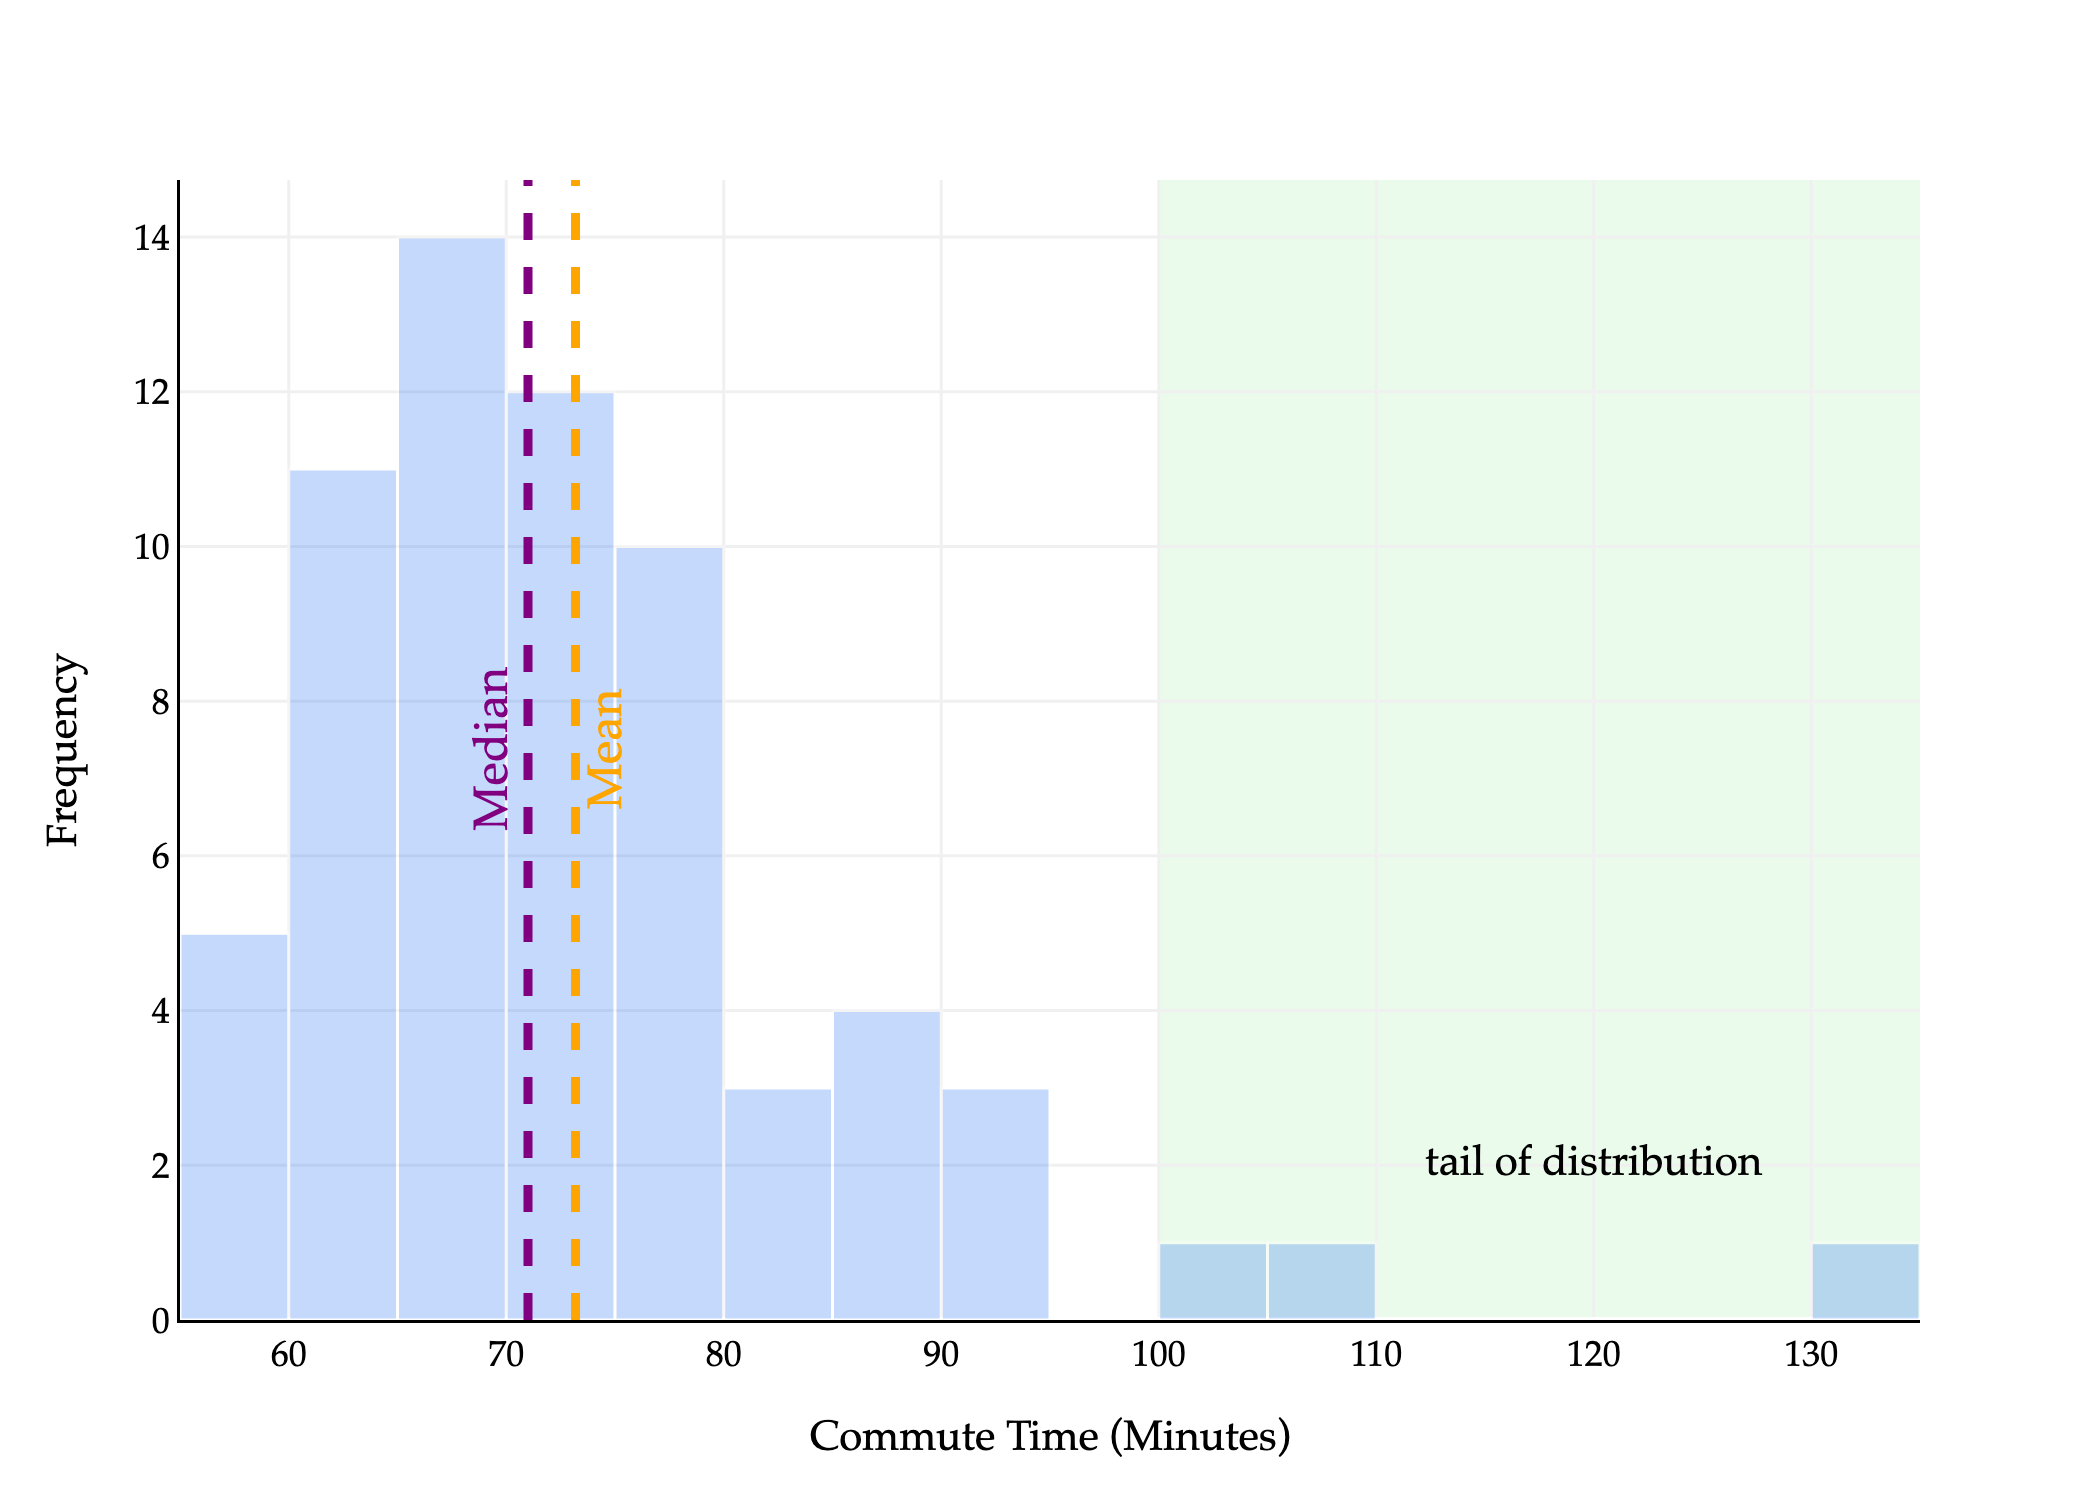

In [36]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('data/commute-times.csv')

mean_val = df['minutes'].mean()
median_val = df['minutes'].median()

fig = px.histogram(
    df, 
    x='minutes', 
    nbins=20,
    opacity=0.3
)
fig.update_xaxes(
    title='Commute Time (Minutes)', 
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    title='Frequency', 
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

fig.update_traces(marker_line_color='white', marker_line_width=1, marker_color="#3D81F6")
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)

# Add subtle green highlight between 100 and 130 across the entire plane
fig.add_vrect(
    x0=100, x1=135,
    fillcolor="rgba(0,200,0,0.08)",
    layer="below",
    line_width=0,
)

# Add dashed vertical lines for mean (orange) and median (purple)
fig.add_vline(
    x=mean_val,
    line_dash="dash",
    line_color="orange",
    line_width=3,
    annotation_text="Mean",
    annotation_position="right",
    annotation=dict(
        textangle=-90,
        xanchor="left",
        yanchor="middle",
        font=dict(
            color="orange",
            family="Palatino Linotype, Palatino, serif",
            size=16
        )
    )
)

fig.add_vline(
    x=median_val,
    line_dash="dash",
    line_color="purple",
    line_width=3,
    annotation_text="Median",
    annotation_position="left",
    annotation=dict(
        textangle=-90,
        xanchor="right",
        yanchor="middle",
        font=dict(
            color="purple",
            family="Palatino Linotype, Palatino, serif",
            size=16
        )
    )
)

fig.add_annotation(
    x=120,
    y=2,
    text="tail of distribution",
    showarrow=False,
    font=dict(
        color="black",
        family="Palatino Linotype, Palatino, serif",
        size=14
    ),
    xanchor="center"
)

fig.show(renderer='png', scale=3)

The <span style="color:purple; font-weight:bold">median</span> is the point at which half the values are below it and half are above it. In the histogram above, **half of the area is to the left of the median and half is to the right**.

The <span style="color:orange; font-weight:bold">mean</span> is the point at which the sum of deviations from each value to the mean is 0. Another interpretation: if you placed this histogram on a playground see-saw, the mean would be the point at which the see-saw is balanced. [Wikipedia](https://commons.m.wikimedia.org/wiki/Category:Arithmetic_mean#/media/File%3ASeesaw_with_mean.svg) has a good illustration of this general idea.

We say the distribution above is **right-skewed** or **right-tailed** because the tail is on the right side of the distribution. (This is counterintuitive to me, because most of the data is on the left of the distribution.)

In general, the mean is pulled in the direction of the tail of a distribution:
- If a distribution is symmetric, i.e. has roughly the same-shaped tail on the left and right, the mean and median are similar.
- If a distribution is right-skewed, the mean is pulled to the right of the median, i.e. $\text{Mean} > \text{Median}$.
- If a distribution is left-skewed, the mean is pulled to the left of the median, i.e. $\text{Mean} < \text{Median}$.

This explains why ${\color{orange} \text{Mean}} > {\color{purple} \text{Median}}$ in the histogram above, and equivalently, in the scatter plot below.

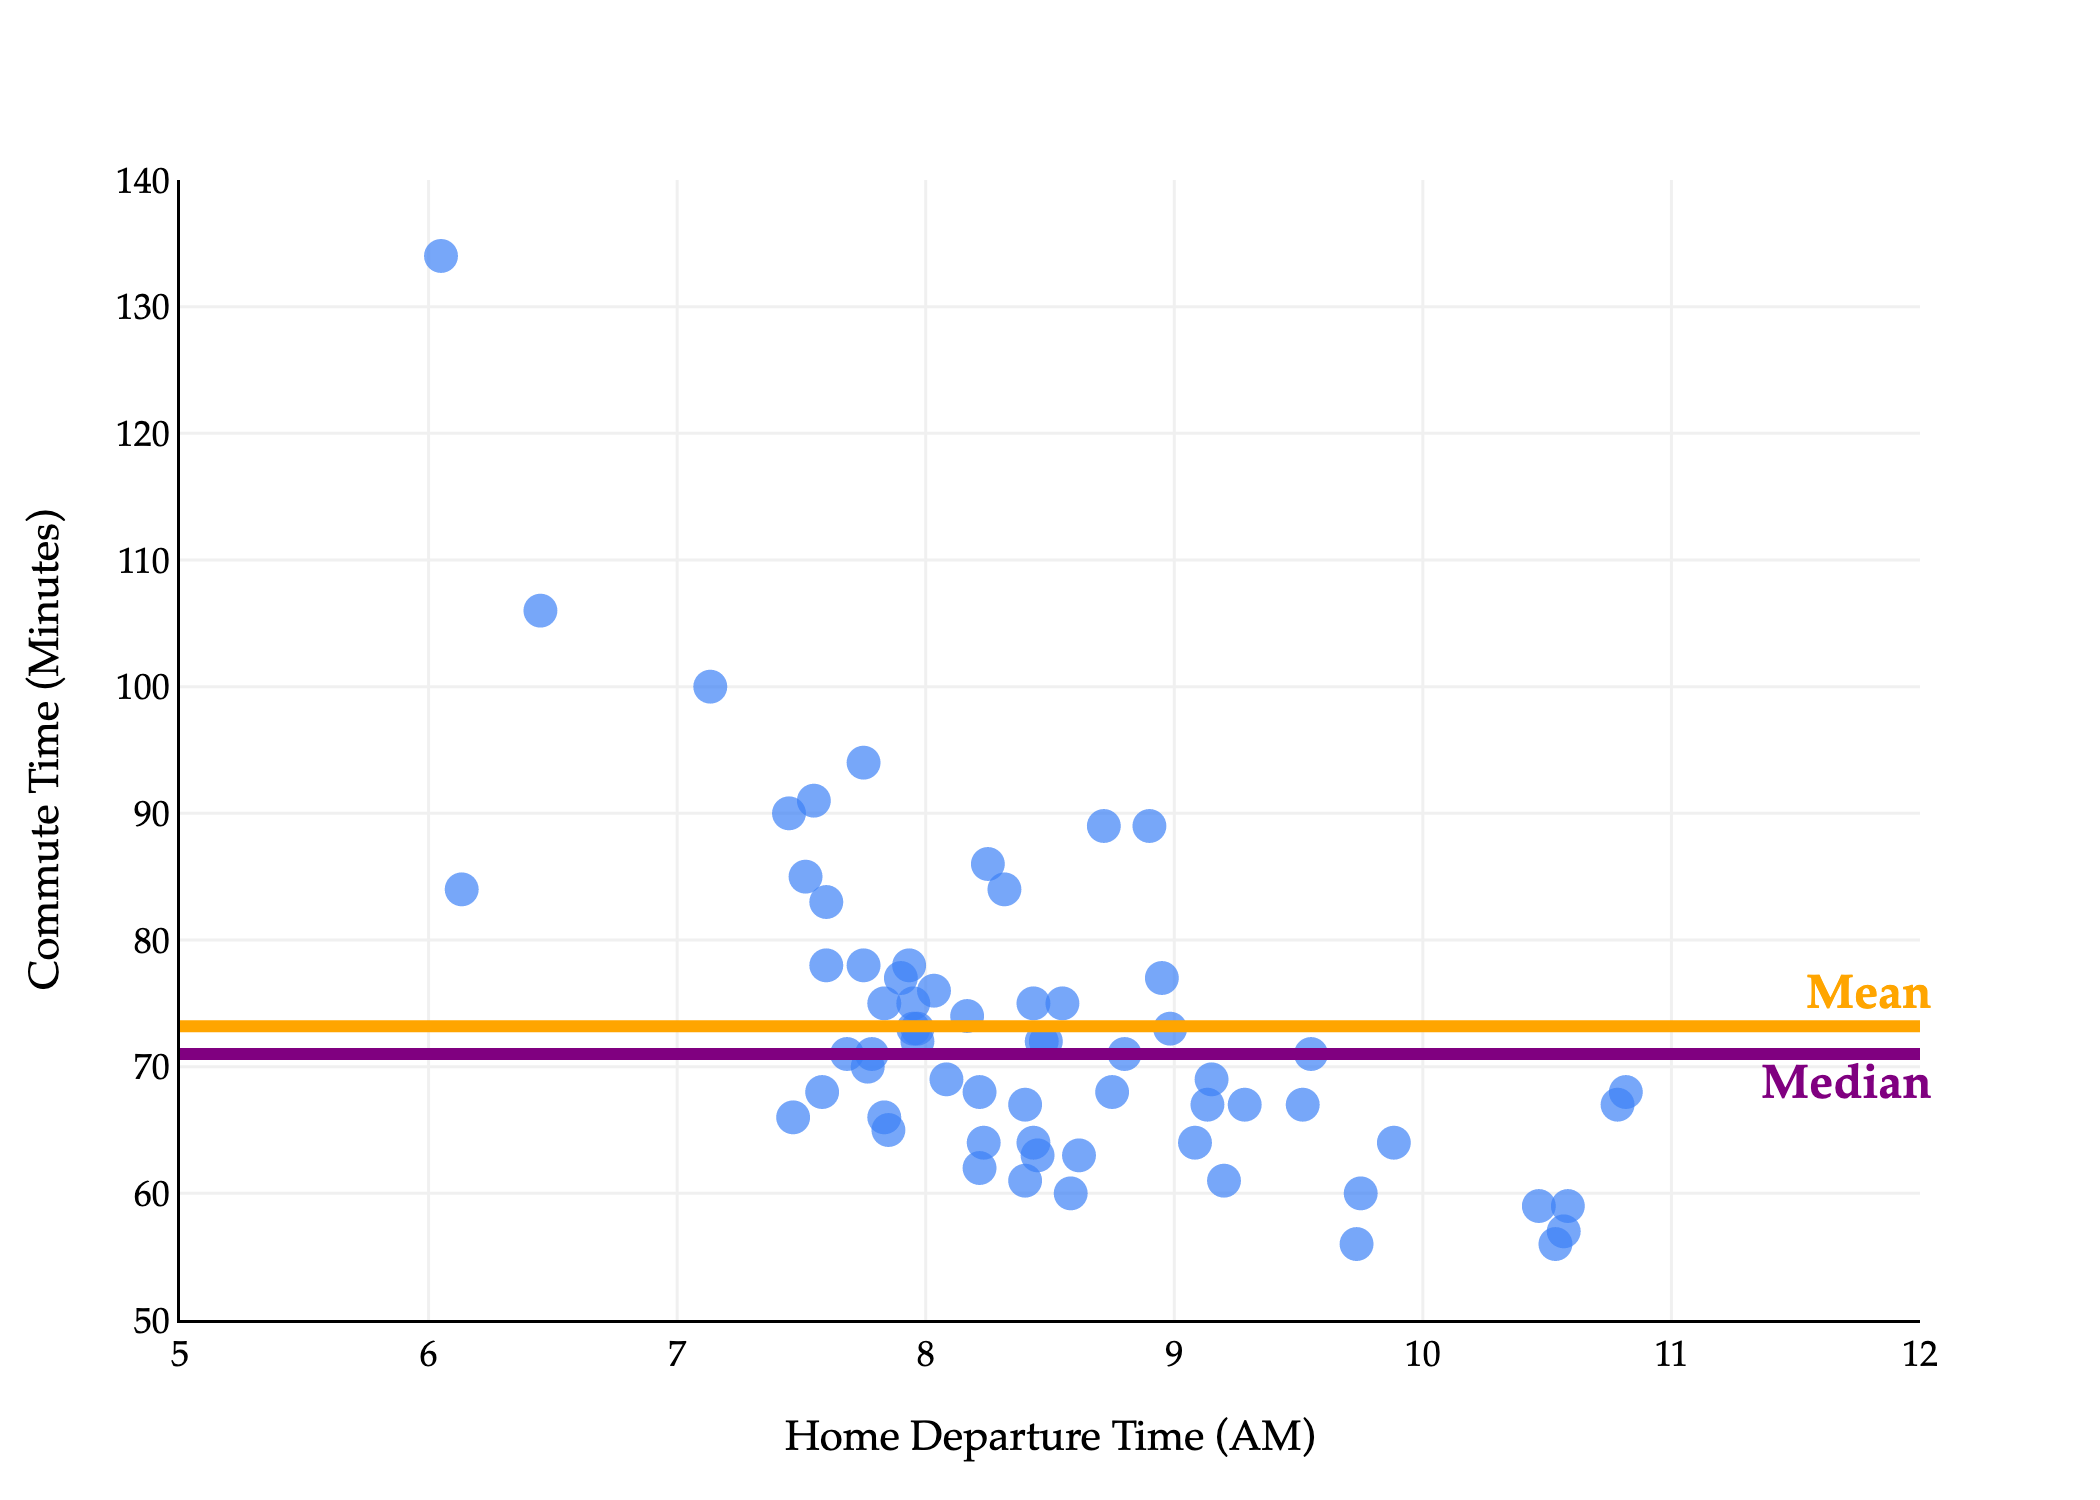

In [38]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv('data/commute-times.csv')
y_mean = df['minutes'].mean()
y_median = df['minutes'].median()

fig = px.scatter(
    df,
    x='departure_hour',
    y='minutes',
    size=np.ones(len(df)) * 50,
    size_max=8
)

fig.add_hline(
    y=y_mean,
    line_color='orange',
    line_width=4
)
fig.add_hline(
    y=y_median,
    line_color='purple',
    line_width=4
)

fig.add_annotation(
    xref="paper",
    yref="y",
    x=1.01,
    y=y_mean,
    text="<b>Mean</b>",
    showarrow=False,
    font=dict(color="orange", size=16),
    align="left",
    yshift=10
)
fig.add_annotation(
    xref="paper",
    yref="y",
    x=1.01,
    y=y_median-5,
    text="<b>Median</b>",
    showarrow=False,
    font=dict(color="purple", size=16),
    align="left",
    yshift=10
)

fig.update_xaxes(
    title='Home Departure Time (AM)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    range=[5, 12]
)
fig.update_yaxes(
    title='Commute Time (Minutes)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_traces(marker_color="#3D81F6", marker_line_width=0)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    showlegend=False,
)
fig.show(renderer='png', scale=3)


Many common distributions in the real world are right-skewed, including incomes and net worths, and in such cases, the mean doesn't tell the full story.

:::{figure} 03-empirical-risk-minimization-imgs/mean-vs-median.png
:width: 70%
:align: center

Mean (average) and median incomes for several countries ([source](https://www.ngpf.org/blog/chart-of-the-week/mean-and-median-income-inequality/)).
:::

When we move to more sophisticated models with (many) more parameters, the optimal parameter values won't be as easily interpretable as the mean and median of our data, but the effects of our choice of loss function will still be felt in the predictions we make.

---

## Beyond Absolute and Squared Loss

You may have noticed that the absolute loss and squared loss functions both look relatively similar:

$$L_\text{abs}({\color{3D81F6}y_i}, {\color{orange}h(x_i)}) = |{\color{3D81F6}y_i}-{\color{orange}h(x_i)}|$$

$$L_\text{sq}({\color{3D81F6}y_i}, {\color{orange}h(x_i)}) = ({\color{3D81F6}y_i}-{\color{orange}h(x_i)})^2$$

Both of these loss functions are special cases of a more general class of loss functions, known as $L_p$ loss functions. For any $p \geq 1$, define the $L_p$ loss as follows:

$$L_p(y_i, h(x_i)) = |{\color{3D81F6}y_i}-{\color{orange}h(x_i)}|^p$$

Suppose we continue to use the constant model, $h(x_i) = w$. Then, the corresponding empirical risk for $L_p$ loss is:

$$R_p(w) = \frac{1}{n} \sum_{i = 1}^n |y_i - w|^p$$

We've studied, in depth, the minimizers of $R_p(w)$ for $p = 1$ (the median) and $p = 2$ (the mean). What about when $p = 3$, or $p = 4$, or $p = 100$? What happens as $p \rightarrow \infty$?

Let me be a bit less abstract. Suppose we have $p = 6$. Then, we're looking for the constant prediction $w$ that minimizes the following:

$$R_6(w) = \frac{1}{n} \sum_{i = 1}^n |y_i - w|^6 = \frac{1}{n} \sum_{i = 1}^n (y_i - w)^6$$

Note that I dropped the absolute value, because $(y_i - w)^6$ is always non-negative, since 6 is an even number.

To find $w^*$ here, we need to take the derivative of $R_6(w)$ with respect to $w$ and set it equal to 0.

$$\frac{\text{d}}{\text{d}w} R_6(w) = -\frac{6}{n} \sum_{i = 1}^n (y_i - w)^5$$

Setting the above to 0 gives us a new balance condition: $\displaystyle\sum_{i = 1}^n (y_i - w)^5 = 0$. The minimizer of $R_2(w)$ was the point at which the balance condition $\displaystyle\sum_{i = 1}^n (y_i - w) = 0$ was satisfied; equivalently, the minimizer of $R_6(w)$ is the point at which the balance condition $\displaystyle\sum_{i = 1}^n (y_i - w)^5 = 0$ is satisfied. You'll notice that the degree of the differences in the balance condition is one lower than the degree of the differences in the loss function --- this comes from the power rule of differentiation.

At what point $w^*$ does $\displaystyle\sum_{i = 1}^n (y_i - w^*)^5 = 0$? It's challenging to determine the value by hand, but the computer can approximate solutions for us, as you'll see in Lab 2.

Below, you'll find a computer-generated graph where:
- The $x$-axis is $p$.
- The $y$-axis represents the value of $w^*$ that minimizes $R_p(w)$, for the dataset $$61 \qquad 72 \qquad 85 \qquad 90 \qquad 292$$ that we saw earlier. Note the maximum value in our dataset is $292$.

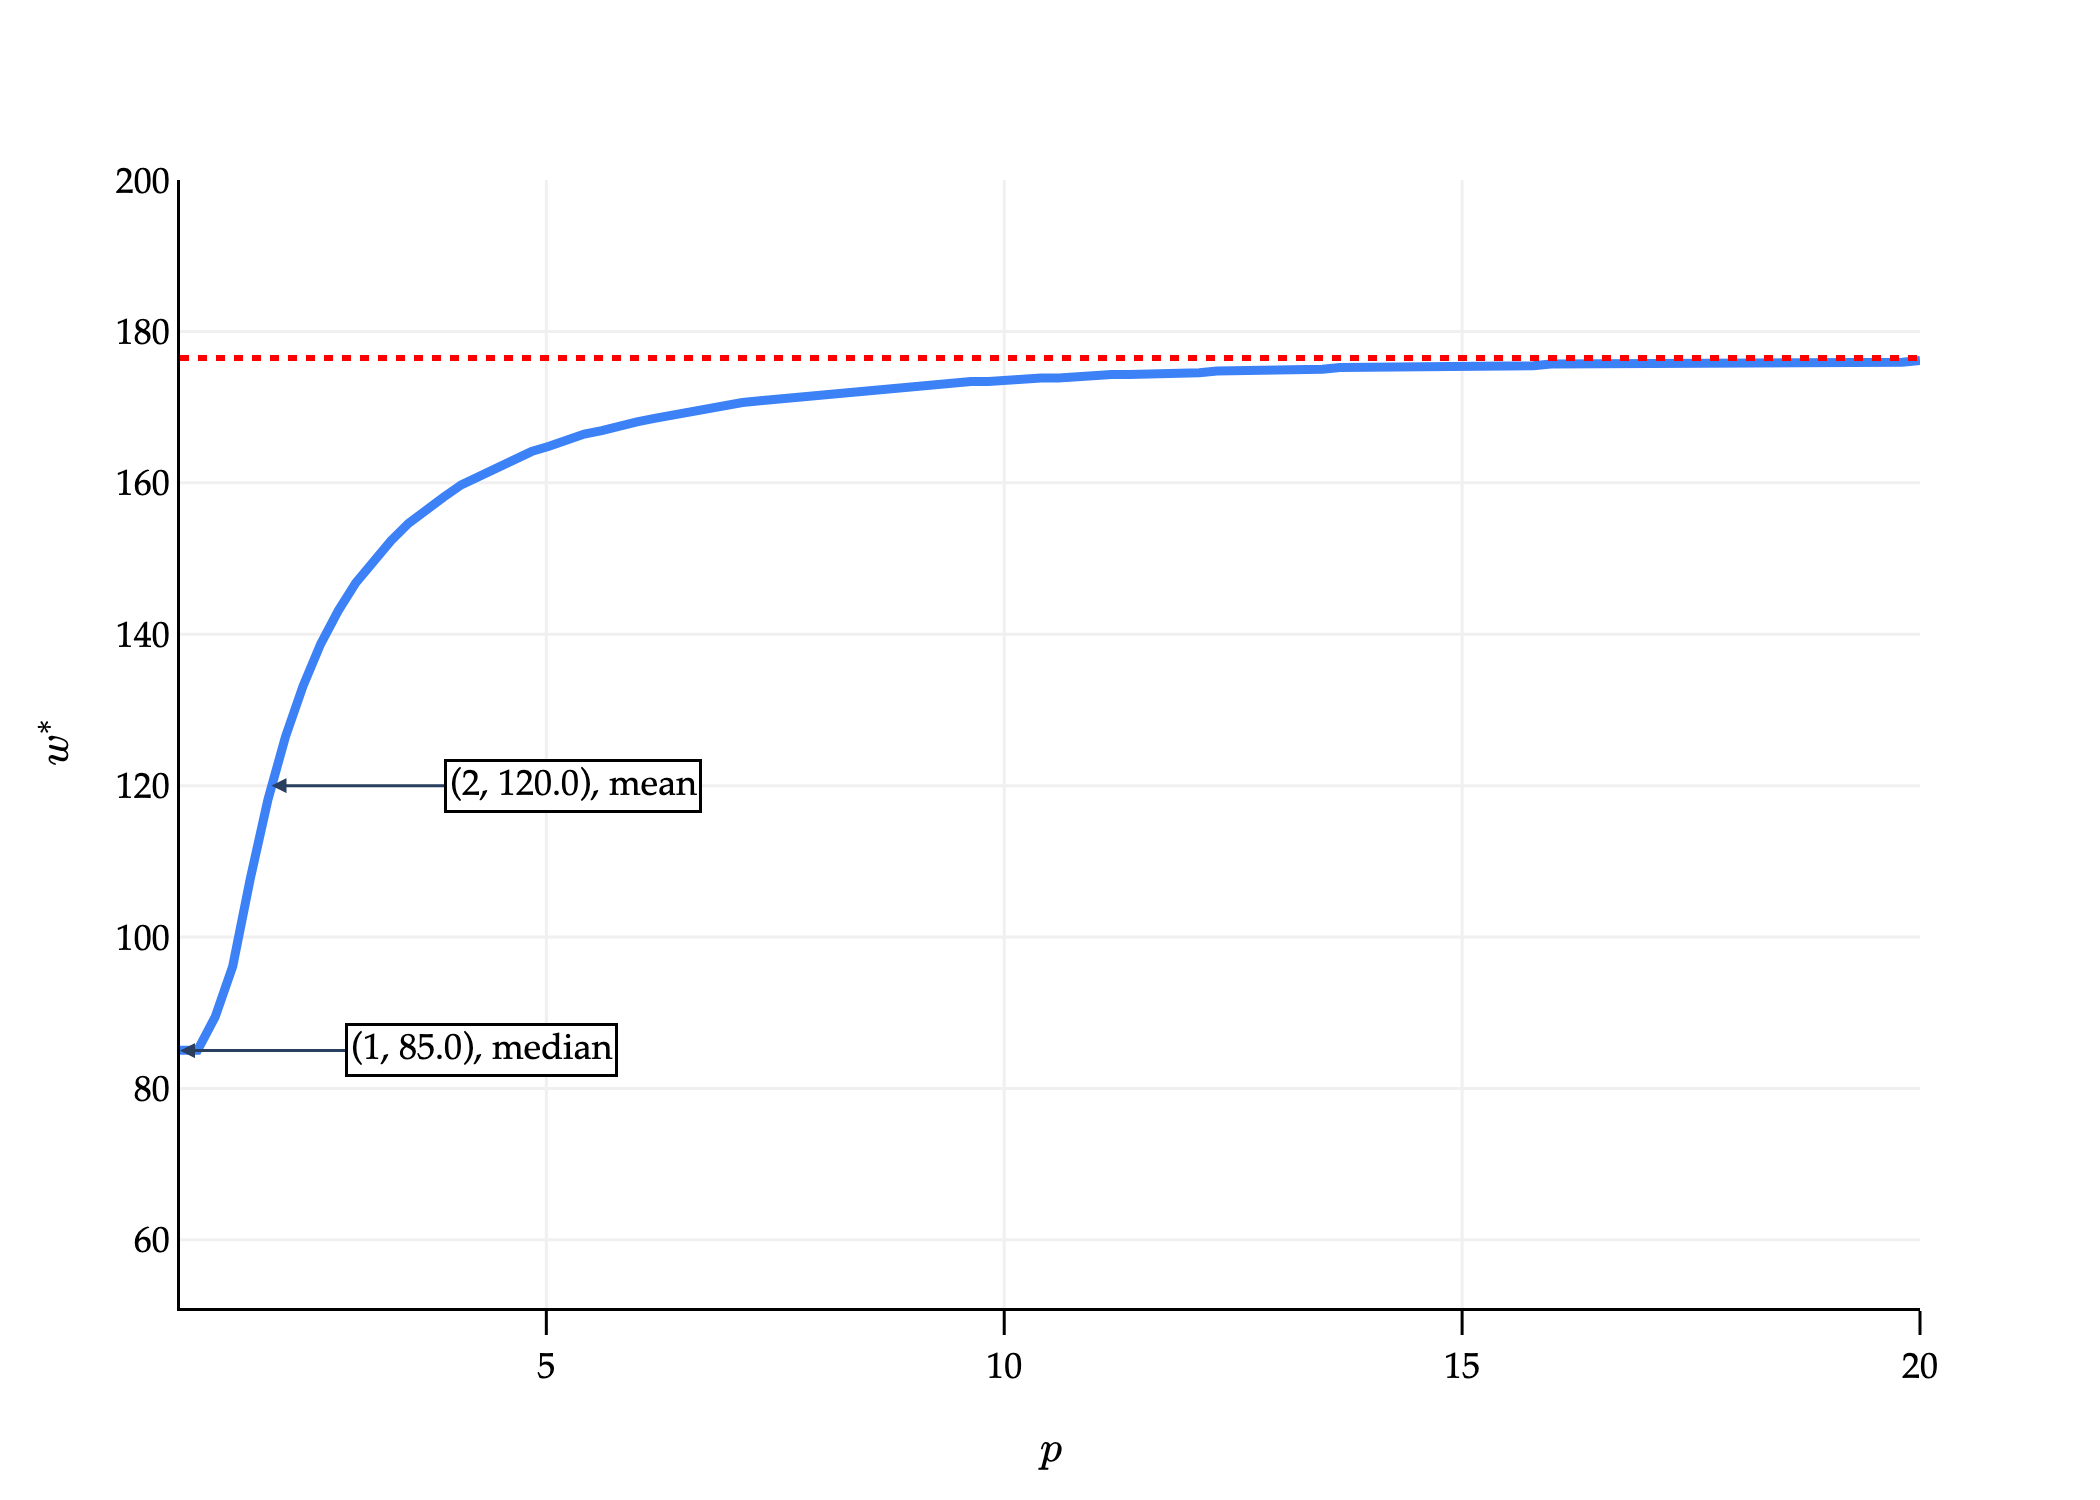

In [41]:
import numpy as np
import plotly.graph_objects as go

# Corrected dataset
y = np.array([61, 72, 85, 90, 292])

# Range of p values
p_values = np.linspace(1, 20, 100)
w_stars = []

# For each p, numerically find the minimizer of average L_p loss
for p in p_values:
    ws = np.linspace(np.min(y), np.max(y), 1000)
    risks = np.array([np.mean(np.abs(y - w)**p) for w in ws])
    min_idx = np.argmin(risks)
    w_stars.append(ws[min_idx])

# For p = infinity, the minimizer is the midpoint of min and max
w_star_inf = (np.min(y) + np.max(y)) / 2

# Calculate median and mean for labels
median_val = np.median(y)
mean_val = np.mean(y)

# Plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=p_values,
    y=w_stars,
    mode='lines',
    line=dict(color='#3D81F6', width=3),
    name='Minimizer $w^*$',
    showlegend=False
))

# Add horizontal line for p = infinity minimizer
fig.add_trace(go.Scatter(
    x=[p_values[0], p_values[-1]],
    y=[w_star_inf, w_star_inf],
    mode='lines',
    line=dict(color='red', width=2, dash='dot'),
    name='$w^*$ as $p \\to \\infty$',
    showlegend=False
))

# Add labels at p=1 (median) and p=2 (mean)
fig.add_annotation(
    x=1,
    y=median_val,
    text=f"(1, {median_val}), median",
    showarrow=True,
    arrowhead=2,
    ax=100,
    ay=0,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black",
        size=12
    ),
    bgcolor="white",
    bordercolor="black",
    borderwidth=1
)

fig.add_annotation(
    x=2,
    y=mean_val,
    text=f"(2, {mean_val}), mean",
    showarrow=True,
    arrowhead=2,
    ax=100,
    ay=0,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black",
        size=12
    ),
    bgcolor="white",
    bordercolor="black",
    borderwidth=1
)

fig.update_layout(
    xaxis=dict(
        title='$p$',
        showticklabels=True,
        visible=True,
        ticks='outside',
        tickcolor='black',
        ticklen=8,
        gridcolor='#f0f0f0',
        linecolor="black",  
        linewidth=1,
        range=[1, 20],  # <-- Set x-axis to start from 1
    ),
    yaxis=dict(
        title='$w^*$',
        showticklabels=True,
        visible=True,
        range=[np.min(y)-10, 200],
        gridcolor='#f0f0f0',
        linecolor="black",  
        linewidth=1,        
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
)

fig.show(renderer='png', scale=3)


As $p \rightarrow \infty$, $w^*$ approaches some value.

:::{tip} Activity 1
:class: dropdown
As $p \rightarrow \infty$, what value does $w^*$ approach, and why?

:::{seealso} Solution
:class: dropdown

As $p \rightarrow \infty$, $w^*$ approaches:

$$\text{midrange} = \frac{\text{min} + \text{max}}{2}$$

Intuitively, as $p \rightarrow \infty$, we're minimizing the **worst-case distance** to any point in the dataset, i.e. the maximum distance to any point in the dataset. To keep the maximum distance as small as possible, we need to be directly in between the two extreme points of the dataset. Think of this as a "tug-of-war" between the minimum and maximum values of the dataset.
:::

On the other extreme end, let me introduce yet another loss function, **0-1 loss**:

$$L_{0,1}(y_i, h(x_i)) = \begin{cases} 0 & y_i = h(x_i) \\ 1 & y_i \neq h(x_i) \end{cases}$$

The corresponding empirical risk, for the constant model $h(x_i) = w$, is:

$$R_{0,1}(w) = \frac{1}{n} \sum_{i = 1}^n L_{0, 1}(y_i, w)$$

This is the sum of 0s and 1s, divided by $n$. A 1 is added to the sum each time $y_i \neq w$. So, in other words, $R_{0,1}(w)$ is:

$$R_{0,1}(w) = \frac{\text{number of points not equal to } w}{n}$$

To minimize empirical risk, we want the number of points not equal to $w$ to be as small as possible. So, $w^*$ is the **mode (i.e. most frequent value)** of the dataset. If all values in the dataset are unique, they all minimize average 0-1 loss. This is not a useful loss function for regression, since our predictions are drawn from the continuous set of real numbers, but is useful for classification.

---

## Center and Spread

Prior to taking EECS 245, you knew about the mean, median, and mode of a dataset. What you now know is that each one of these **summary statistics** comes from minimizing empirical risk (i.e. average loss) for a different loss function. All three measure the **center** of the dataset in some way.

| Loss | Minimizer of Empirical Risk | Always Unique? | Robust to Outliers? | Empirical Risk Differentiable? |
| --- | --- | --- | --- | --- |
| $L_\text{sq}$ | mean | yes ✅ | no ❌ | yes ✅ |
| $L_\text{abs}$ | median | no ❌ | yes ✅ | no ❌ |
| $L_\infty$ | midrange | yes ✅ | no ❌ | no ❌ |
| $L_\text{0,1}$ | mode | no ❌ | no ❌ | no ❌ |

So far, we've focused on finding model parameters that minimize empirical risk. But, we never stopped to think about what the minimum empirical risk itself is! Consider the empirical risk for squared loss and the constant model:

$$R_\text{sq}(w) = \frac{1}{n} \sum_{i = 1}^n (y_i - w)^2$$

$R_\text{sq}(w)$ is minimized when $w^*$ is the mean, which I'll denote with $\bar{y}$. What happens if I plug $w^* = \bar{y}$ back into $R_\text{sq}$?

$$R_\text{sq}(w^*) = R_\text{sq}(\bar{y}) = {\color{orange}\frac{1}{n} \sum_{i = 1}^n} {\color{#d81b60}(y_i - \bar{y})}^{\color{#3d81f6}2}$$

This is the **variance** of the dataset $y_1, y_2, ..., y_n$! The variance is nothing but the <span style="color:orange; font-weight:bold">average</span> <span style="color:#3d81f6; font-weight:bold">squared</span> <span style="color:#d81b60; font-weight:bold">deviation</span> of each value from the mean of the dataset.

This gives context to the $y$-axis value of the vertex of the parabola we saw in [Chapter 1.2](02-squared-loss-constant-model.ipynb).

$$R_\text{sq}(w) = \frac{1}{n} \sum_{i = 1}^n (y_i - w)^2$$

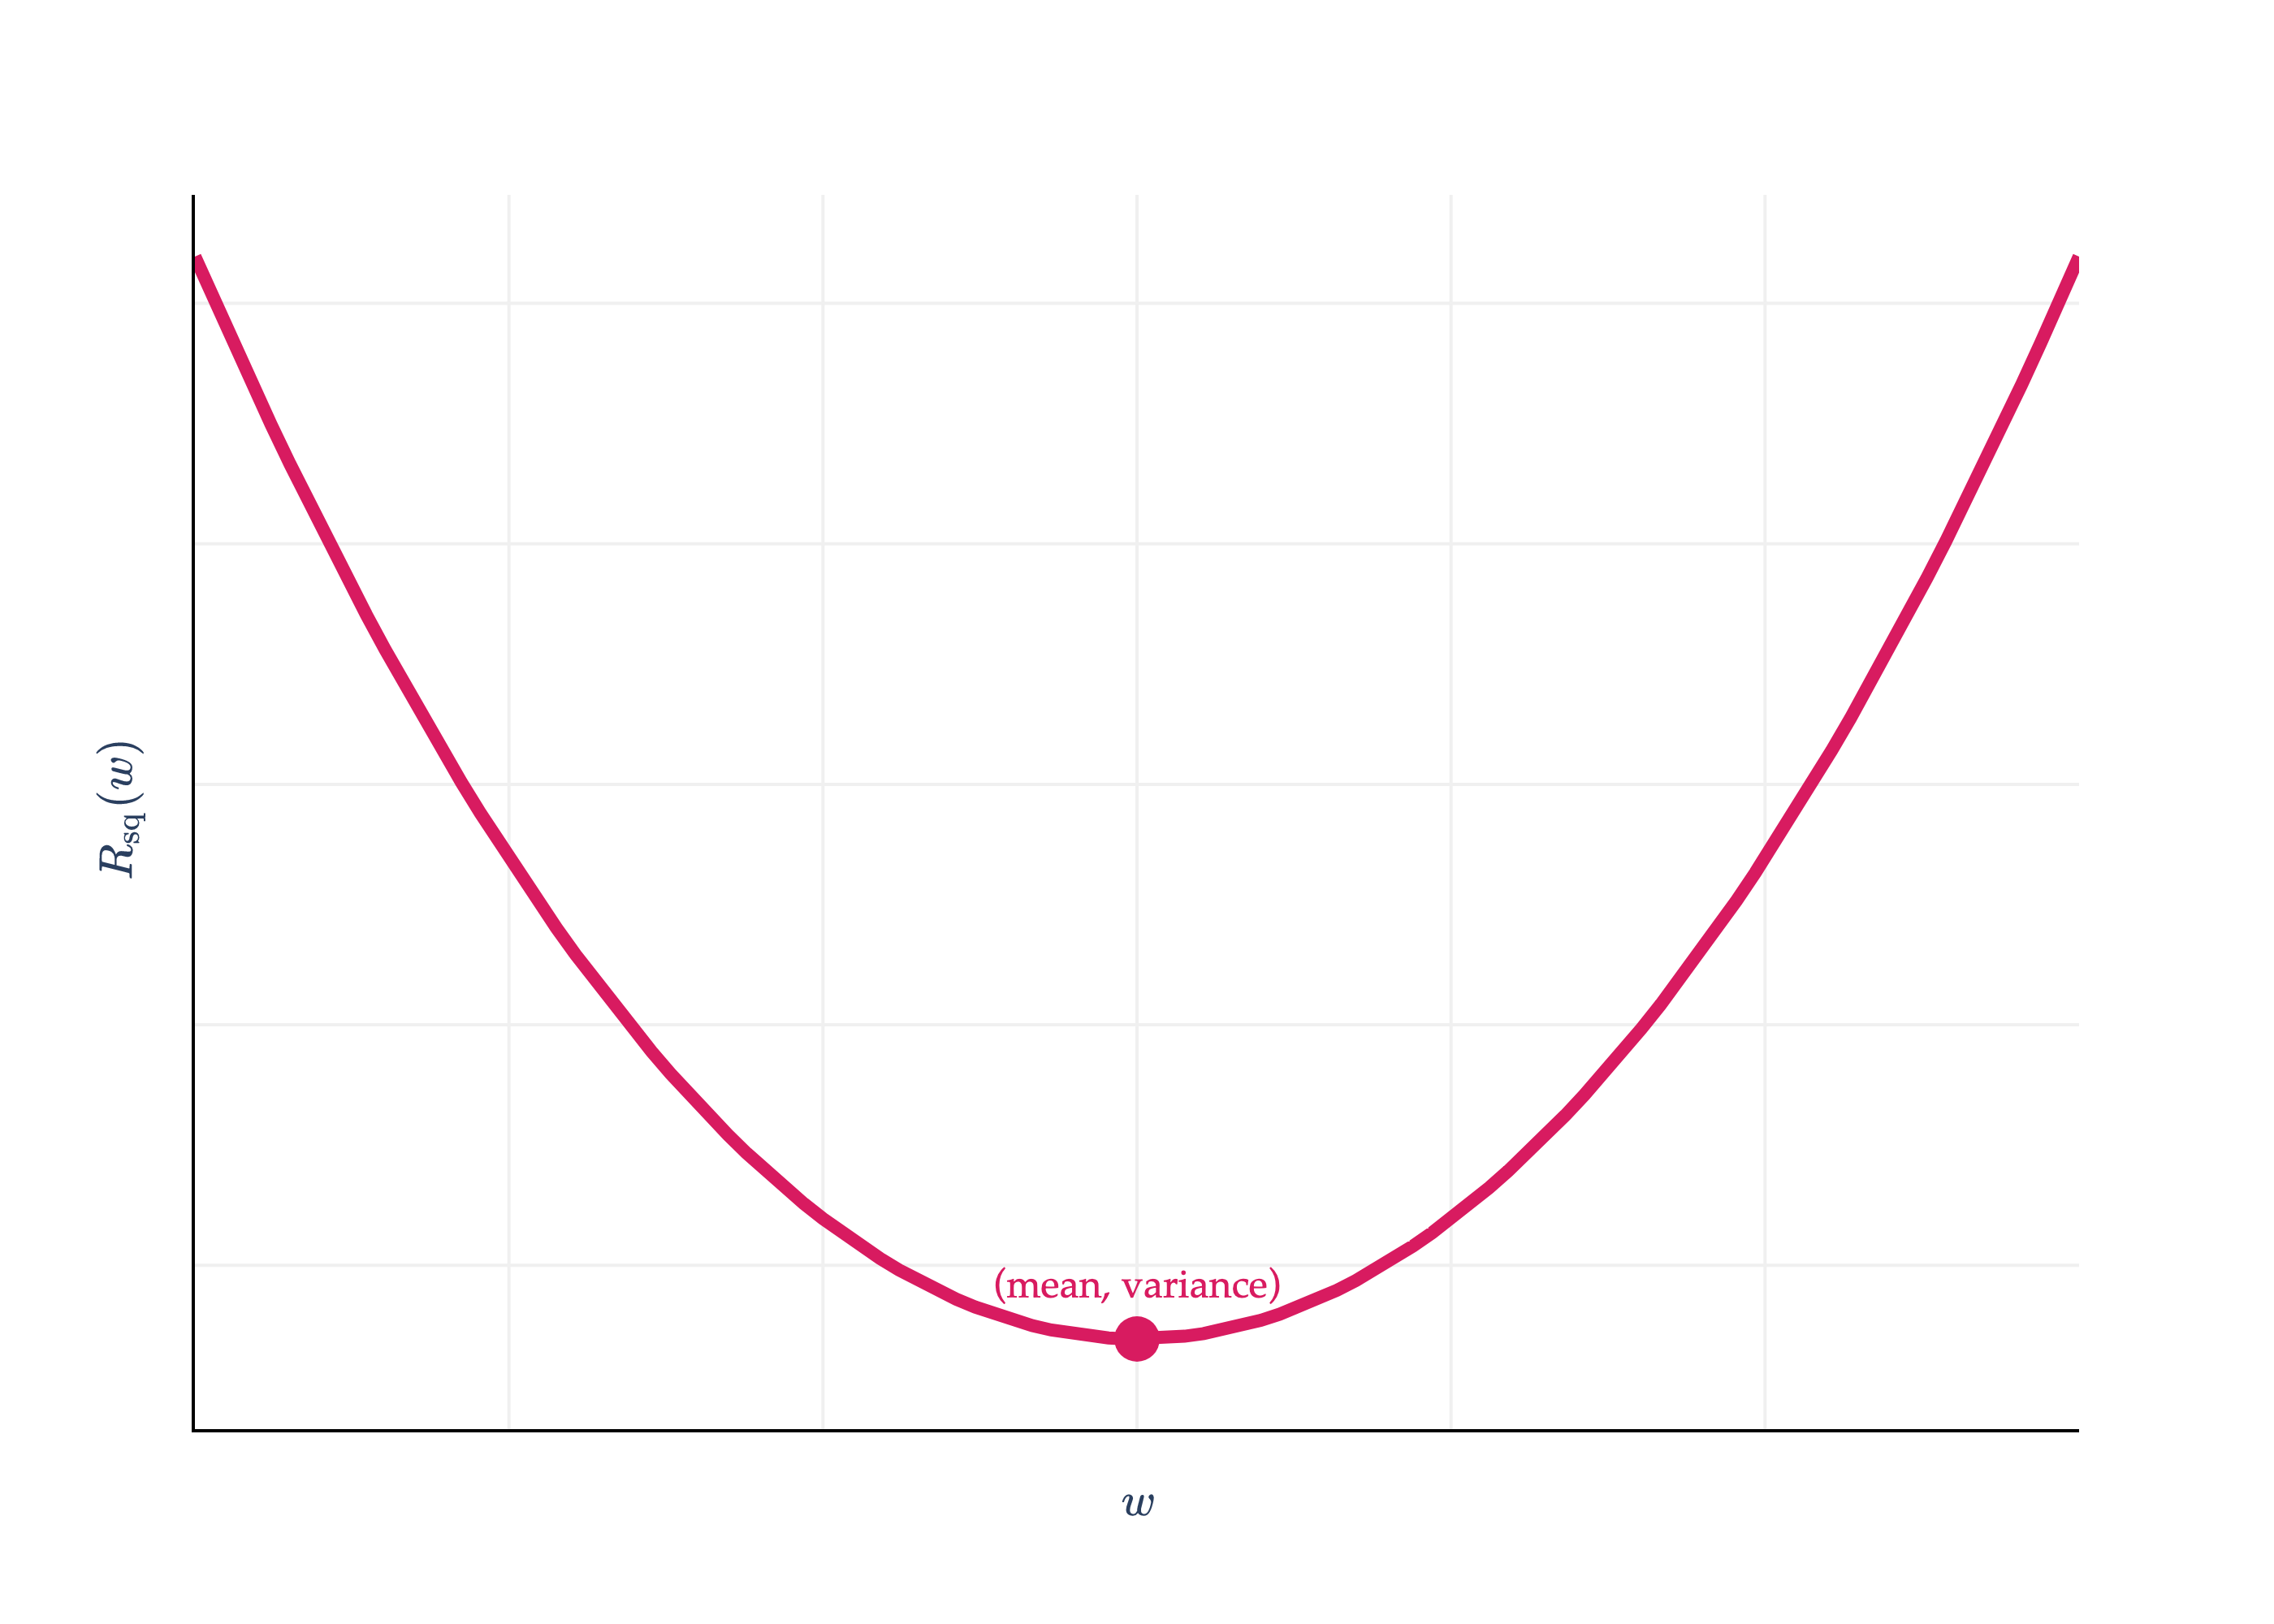

In [60]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('data/commute-times.csv')

f = lambda h: ((72-h)**2 + (90-h)**2 + (61-h)**2 + (85-h)**2 + (92-h)**2) / 5

x = np.linspace(50, 110, 100)
y = np.array([f(h) for h in x])

# Calculate mean and variance
data = np.array([72, 90, 61, 85, 92])
mean = np.mean(data)
variance = np.mean((data - mean) ** 2)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x, 
        y=y, 
        mode='lines', 
        name='Data', 
        line=dict(color='#D81B60', width=4)
    )
)

# Draw a point at the vertex (mean, variance)
fig.add_trace(
    go.Scatter(
        x=[mean],
        y=[variance],
        mode='markers+text',
        marker=dict(color='#D81B60', size=14, symbol='circle'),
        text=[f"<span style='font-family:Palatino, Palatino Linotype, serif; color:#D81B60'>(mean, variance)</span>"],
        textposition="top center",
        showlegend=False
    )
)

fig.update_xaxes(
    showticklabels=False,
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    showticklabels=False
)

fig.update_layout(
    xaxis_title=r'$w$',
    yaxis_title=r'$R_\text{sq}(w)$',
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        # color="black"
    ),
    showlegend=False
)

fig.show(renderer='png', scale=4)

Practically speaking, this gives us a nice "worst-case" mean squared error of any regression model on a dataset. If we learn how to build a sophisticated regression model, and its mean squared error is somehow greater than the variance of the dataset, we know that we're doing something wrong, since we could do better just by predicting the mean!

The units of the variance are the square of the units of the $y$-values. So, if the $y_i$'s represent commute times in minutes, the variance is in $\text{minutes}^2$. This makes it a bit difficult to interpret. So, we typically take the square root of the variance, which gives us the standard deviation, $\sigma$:

$$\sigma = \sqrt{\text{variance}} = \sqrt{\frac{1}{n} \sum_{i = 1}^n (y_i - \bar{y})^2}$$

The standard deviation has the same units as the $y$-values themselves, so it's a more interpretable measure of spread.

How does this work in the context of absolute loss?

$$R_\text{abs}(w) = \frac{1}{n} \sum_{i = 1}^n |y_i - w|$$

Plugging in $w^* = \text{Median}(y_1, y_2, ..., y_n)$ into $R_\text{abs}(w)$ gives us:
$$\begin{align*} R_\text{abs}(w^*) &= \frac{1}{n} \sum_{i = 1}^n |y_i - w^*| \\ &= \frac{1}{n} \sum_{i = 1}^n |y_i - \text{Median}(y_1, y_2, ..., y_n)| \end{align*}$$

I'll admit, this result doesn't have a special name. It is the **mean absolute deviation from the median**. And, like the variance and standard deviation, it measures roughly how far **spread out** the data is from its center. Its units are the same as the $y$-values themselves (since there's no squaring involved).

$$R_\text{abs}(w) = \frac{1}{n} \sum_{i = 1}^n |y_i - w|$$

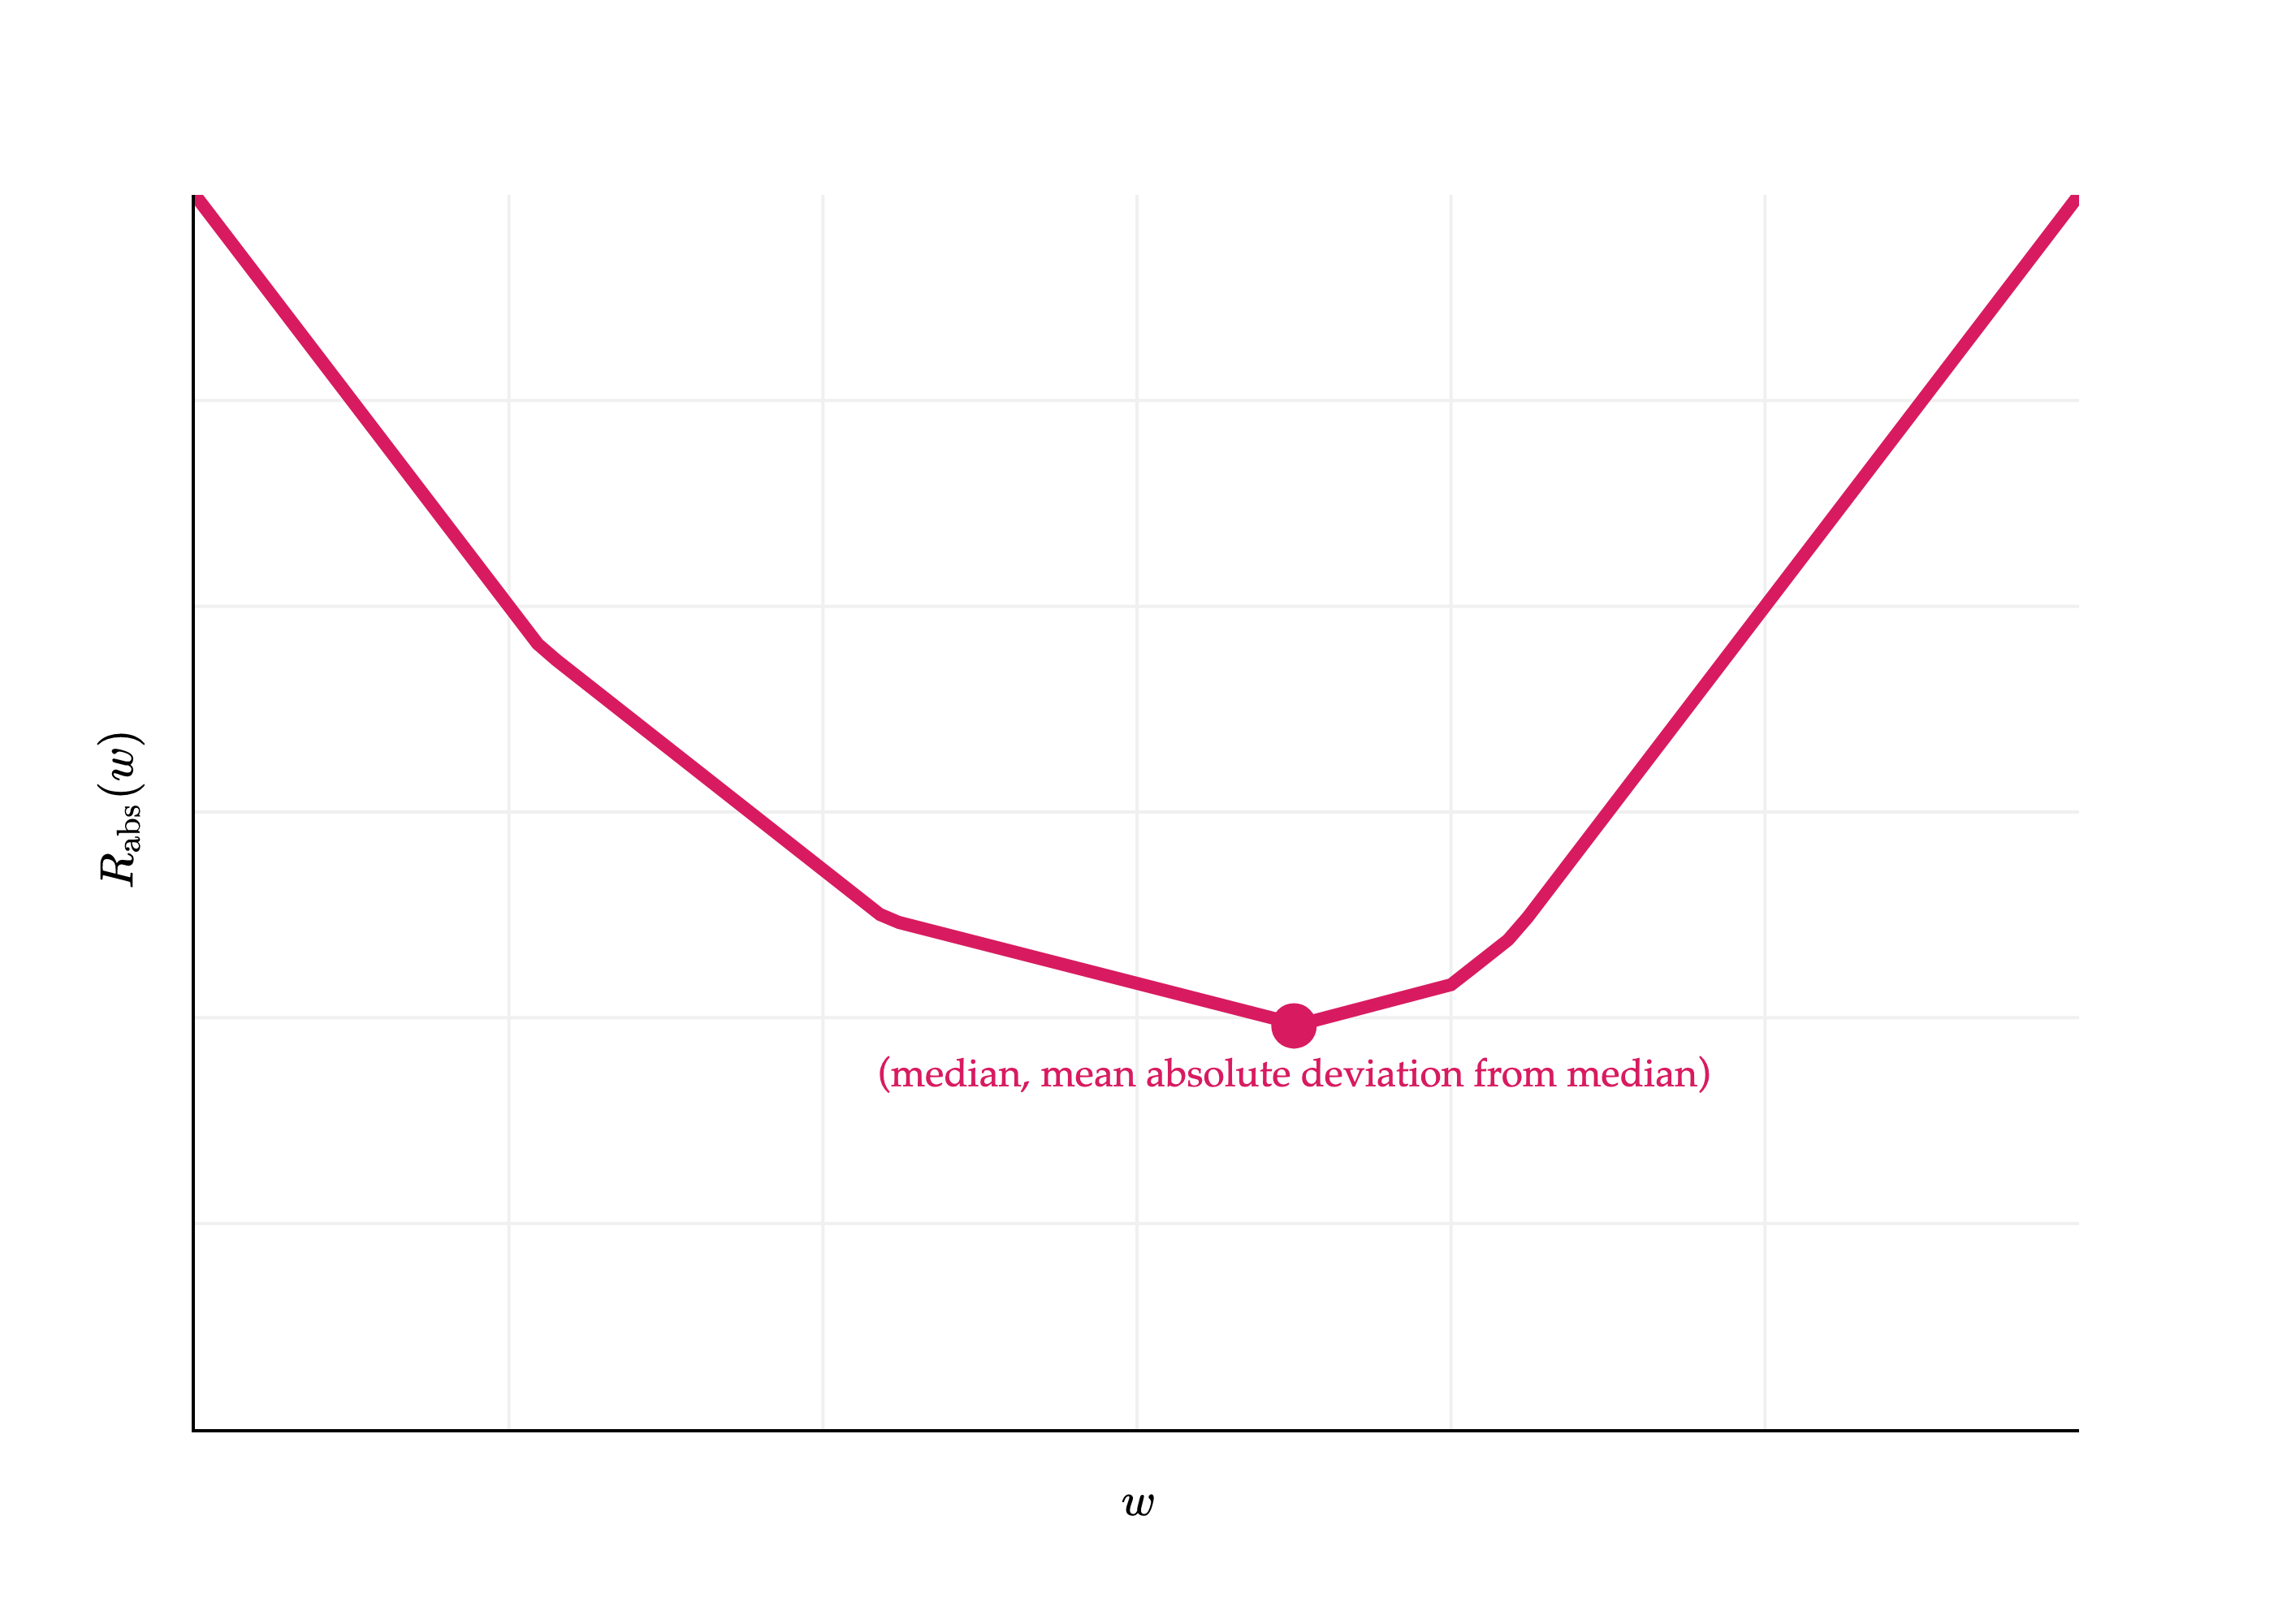

In [63]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('data/commute-times.csv')

f = lambda h: (abs(72-h) + abs(90-h) + abs(61-h) + abs(85-h) + abs(92-h)) / 5

x = np.linspace(50, 110, 100)
y = np.array([f(h) for h in x])

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x, 
        y=y, 
        mode='lines', 
        name='Data', 
        line=dict(color='#D81B60', width=4)
    )
)

fig.update_xaxes(
    showticklabels=False,
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

fig.update_yaxes(
    showgrid=True,
    showticklabels=False,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
    range=[0, 30]
)

median = np.median(data)
mean_abs_deviation = np.mean(np.abs(data - median))

fig.add_trace(
    go.Scatter(
        x=[median],
        y=[mean_abs_deviation],
        mode='markers+text',
        marker=dict(color='#D81B60', size=14, symbol='circle'),
        text=[f"<span style='font-family:Palatino, Palatino Linotype, serif; color:#D81B60'>(median, mean absolute deviation from median)</span>"],
        textposition="bottom center",
        showlegend=False
    )
)

fig.update_layout(
    xaxis_title=r'$w$',
    yaxis_title=r'$R_\text{abs}(w)$',
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    showlegend=False
)

fig.show(renderer='png', scale=4)

:::{tip} Activity 2
:class: dropdown


Consider the dataset:

$$1 \qquad 3 \qquad 5 \qquad 7 \qquad 64$$

Compute the following:

1. The variance.
1. The mean squared error of the **median**.
1. The mean absolute deviation from the **median**.
1. The mean absolute deviation from the **mean**.

What do you notice about the results to (1) and (2)? What about the results to (3) and (4)?

:::

In the real-world, be careful when you hear the term "mean absolute deviation", as sometimes it's used to refer to the median absolute deviation from the mean, not the median as above.

:::{tip} Activity 3
:class: dropdown
What is the value of $R_{0,1}(w^*)$ for the constant model $h(x_i) = w$ and 0-1 loss? How does it measure the spread of the data?
:::

To reiterate, in practice, our models will have many, many more parameters than just one, as is the case for the constant model. But, by deeply studying the effects of choosing squared loss vs. absolute loss vs. other loss functions in the context of the constant model, we can develop a better intuition for how to choose loss functions in more complex situations.